In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from gates.or_gate import or_gate
from gates.and_gate import and_gate
from gates.xor_gate import xor_gate
from gates.full_adder import full_adder
from gates.mux_4_x_1 import mux_4_x_1
from run_circuit import aer_simulator

ModuleNotFoundError: No module named 'quantum_alu'

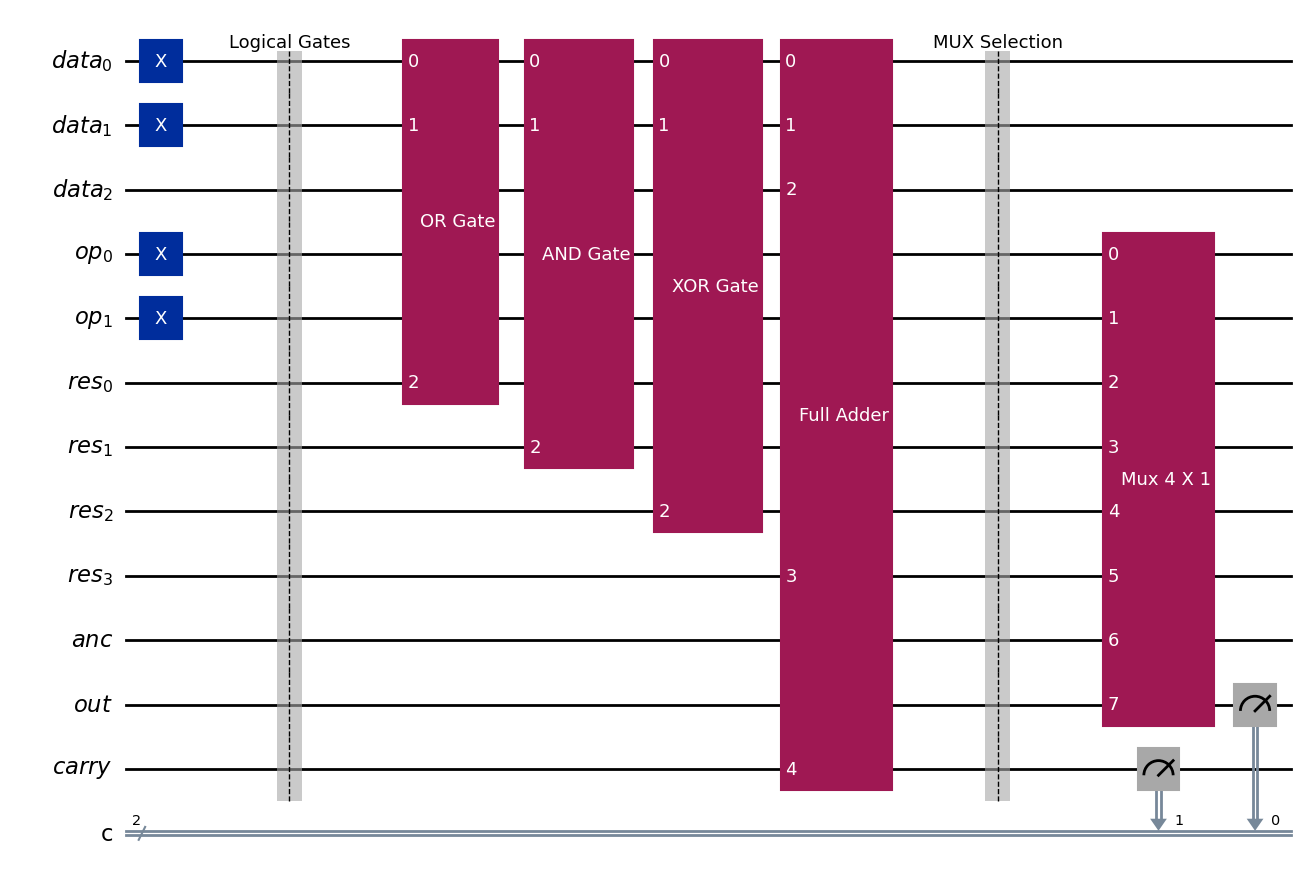

Aer Simulator Measurement Result:  {'10': 1024}


In [9]:
data = QuantumRegister(3, "data")
op = QuantumRegister(2, "op")
res = QuantumRegister(4, "res")
anc = QuantumRegister(1, "anc")
out = QuantumRegister(1, "out")
carry = QuantumRegister(1, "carry")

c = ClassicalRegister(2, "c")

alu = QuantumCircuit(data, op, res, anc, out, carry, c)


alu.x(0)
alu.x(1)
# alu.x(2)

alu.x(3)
alu.x(4)

alu.barrier(label="Logical Gates")
alu.append(or_gate().to_gate(), [0, 1, 5])
alu.append(and_gate().to_gate(), [0, 1, 6])
alu.append(xor_gate().to_gate(), [0, 1, 7])
alu.append(full_adder().to_gate(), [0, 1, 2, 8, 11])

alu.barrier(label="MUX Selection")
alu.append(mux_4_x_1().to_gate(), [3, 4, 5, 6, 7, 8, 9, 10])
alu.measure([10, 11], [0, 1])

display(alu.draw("mpl"))

aer_simulator(alu, shots=1024)
# ibm_fake_simulator(alu, shots=1024)
# ibm_quantum_hardware(alu, shots=1024)